In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/Users/jasleenkaur/Event-Driven-Congestion/data/raw/Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv")

In [3]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (8173, 46)


In [4]:
drop_cols = [
    "map_file",
    "comment",
    "meta_data",
    "direction",
    "resolved_at_address",
    "resolved_at_latitude",
    "resolved_at_longitude",
    "resolved_by_id",
    "resolved_datetime",
    "citizen_accident_id",
    "assigned_to_police_id",
    "route_path",
    "cargo_material",
    "age_of_truck",
    "reason_breakdown"
]

df.drop(columns=drop_cols, inplace=True)

In [5]:
print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (8173, 31)


In [6]:
df["start_datetime"] = pd.to_datetime(
    df["start_datetime"],
    errors="coerce"
)

In [7]:
print(
    "Invalid start_datetime rows:",
    df["start_datetime"].isna().sum()
)

Invalid start_datetime rows: 116


In [8]:
df["hour"] = df["start_datetime"].dt.hour

In [9]:
df["day_of_week"] = df["start_datetime"].dt.day_name()

In [10]:
df["day_num"] = df["start_datetime"].dt.dayofweek

In [11]:
df["month"] = df["start_datetime"].dt.month

In [12]:
df["is_weekend"] = (
    df["start_datetime"].dt.dayofweek >= 5
).astype(int)

In [13]:
df["event_cause"] = (
    df["event_cause"]
      .str.lower()
      .str.strip()
)

In [14]:
priority_score = {
    "Low":1,
    "Medium":2,
    "High":3
}

In [15]:
cause_score = {
    "vip_movement":5,
    "procession":5,
    "public_event":4,
    "protest":5,
    "construction":4,
    "congestion":4,
    "accident":4,
    "vehicle_breakdown":2,
    "water_logging":4,
    "tree_fall":3,
    "pot_holes":2,
    "others":1,
    "debris":2,
    "fog / low visibility":3
}

In [16]:
df["priority_score"] = (
    df["priority"]
      .map(priority_score)
      .fillna(1)
)

In [17]:
df["cause_score"] = (
    df["event_cause"]
      .map(cause_score)
      .fillna(2)
)

In [18]:
df["closure_score"] = np.where(
    df["requires_road_closure"],
    3,
    0
)

In [19]:
def get_time_score(hour):
    if 7 <= hour <= 10:
        return 2
    elif 17 <= hour <= 20:
        return 2
    return 0

In [20]:
df["time_score"] = (
    df["hour"]
      .apply(get_time_score)
)

In [21]:
df["weekend_score"] = np.where(
    df["is_weekend"] == 1,
    1,
    0
)

In [22]:
df["eci"] = (
      df["priority_score"]
    + df["cause_score"]
    + df["closure_score"]
    + df["time_score"]
    + df["weekend_score"]
)

In [23]:
print(
    "Missing impact scores:",
    df["eci"].isna().sum()
)

Missing impact scores: 0


In [24]:
df["eci"].describe()

count    8173.000000
mean        5.736816
std         1.847889
min         2.000000
25%         5.000000
50%         5.000000
75%         7.000000
max        13.000000
Name: eci, dtype: float64

In [25]:
def congestion_risk_level(eci):
    if eci >= 10:
        return "High"
    elif eci >= 6:
        return "Medium"
    return "Low"

In [26]:
df["congestion_risk_level"] = (
    df["eci"]
      .apply(congestion_risk_level)
)

In [27]:
print(df["congestion_risk_level"].value_counts())

congestion_risk_level
Low       4218
Medium    3675
High       280
Name: count, dtype: int64


In [28]:
print(
    round(
        df["congestion_risk_level"].value_counts(normalize=True) * 100,
        2
    )
)

congestion_risk_level
Low       51.61
Medium    44.97
High       3.43
Name: proportion, dtype: float64


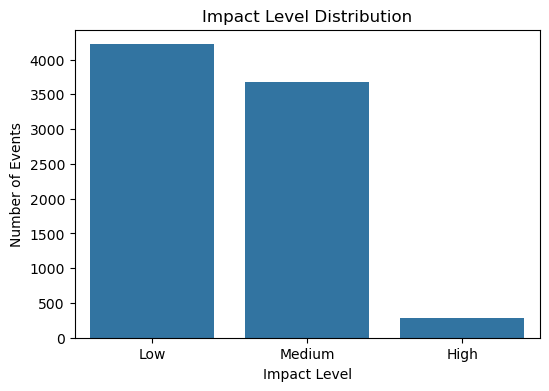

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x="congestion_risk_level",
    data=df,
    order=["Low", "Medium", "High"]
)

plt.title("Impact Level Distribution")
plt.xlabel("Impact Level")
plt.ylabel("Number of Events")

plt.show()

In [30]:
df[df["congestion_risk_level"]=="High"][
    [
        "event_cause",
        "priority",
        "requires_road_closure"
    ]
].head(20)

,event_cause,priority,requires_road_closure
31,vehicle_breakdown,High,True
134,vehicle_breakdown,High,True
229,construction,High,True
241,vip_movement,High,False
291,accident,High,True
357,accident,High,False
378,protest,Low,True
412,construction,High,True
427,water_logging,High,True
440,water_logging,High,False


In [31]:
df[df["congestion_risk_level"]=="High"]["event_cause"].value_counts()

event_cause
construction         87
water_logging        60
vehicle_breakdown    38
tree_fall            23
accident             19
public_event         17
procession           14
vip_movement          6
protest               6
congestion            6
road_conditions       3
others                1
Name: count, dtype: int64

In [32]:
df[df["congestion_risk_level"]=="High"]["requires_road_closure"].value_counts()

requires_road_closure
True     217
False     63
Name: count, dtype: int64

In [33]:
print("Missing values before cleaning:")

print(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

Missing values before cleaning:
end_datetime       7683
end_address        7486
junction           5663
closed_datetime    5032
closed_by_id       5032
zone               4729
gba_identifier     4729
veh_no             3287
veh_type           3286
description        1360
dtype: int64


In [34]:
rows_before = len(df)

In [35]:
df = df.dropna(
    subset=[
        "hour",
        "month",
        "day_of_week"
    ]
)

In [36]:
print(
    "Rows removed:",
    rows_before - len(df)
)

Rows removed: 116


In [37]:
df["corridor"] = df["corridor"].fillna(
    "Unknown"
)

In [38]:
df["zone"] = df["zone"].fillna(
    "Unknown"
)

In [39]:
model_df = df.copy()

In [40]:
model_df["high_congestion_risk"] = np.where(
    model_df["congestion_risk_level"] == "High",
    1,
    0
)

In [41]:
print(model_df.shape)

(8057, 44)


In [42]:
print(model_df["congestion_risk_level"].value_counts())

congestion_risk_level
Low       4201
Medium    3607
High       249
Name: count, dtype: int64


In [43]:
print(model_df["high_congestion_risk"].value_counts())

high_congestion_risk
0    7808
1     249
Name: count, dtype: int64


In [44]:
print(
    model_df[
        [
            "event_type",
            "event_cause",
            "priority",
            "corridor",
            "zone",
            "hour",
            "month",
            "is_weekend",
            "high_congestion_risk"
        ]
    ].isnull().sum()
)

event_type              0
event_cause             0
priority                0
corridor                0
zone                    0
hour                    0
month                   0
is_weekend              0
high_congestion_risk    0
dtype: int64


In [45]:
df.to_csv(
    "../data/processed/events_cleaned.csv",
    index=False
)

In [46]:
model_df.to_csv(
    "../data/processed/model_dataset.csv",
    index=False
)